# Import Libraries

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#Load Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Titanic/train.csv')

# EDA (Exploratory Data Analysis)

In [4]:
# First Five Rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Count Rows and Columns

df.shape

(891, 12)

In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Statistical Summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Column Names

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
# Missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
# Numerical Columns

df.select_dtypes(include=np.number).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [11]:
# Categorical Columns

df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

## Dataset Summary

The Titanic dataset contains 891 rows and 12 columns.
Some columns such as Age, Cabin, and Embarked contain missing values.
The dataset includes both numerical and categorical features.
Passenger information such as age, fare, class, and gender may help predict survival.
This initial exploration provides a good understanding of the dataset before data preprocessing and machine learning.

In [12]:
# Handle Missing Values

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])

## Missing Values Summary

The **Age** column contained missing values, so I filled them using the median because age is a numerical feature and the median is less affected by outliers.

The **Embarked** column had only a few missing values, so I filled them using the most frequent value (mode).

The **Cabin** column had too many missing values (over 75%), so I removed it because it would not provide reliable information for analysis.

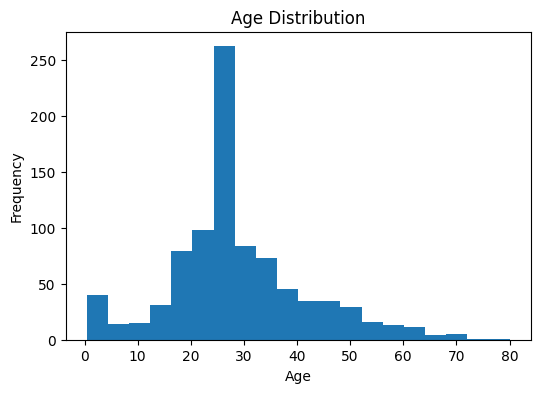

In [13]:
# Histogram

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

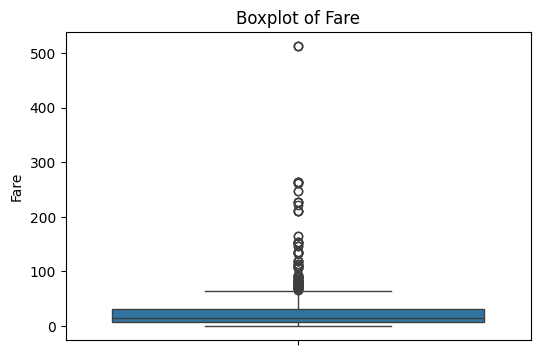

In [14]:
# Boxplot (Outlier Detection)

plt.figure(figsize=(6,4))
sns.boxplot(y=df["Fare"])

plt.title("Boxplot of Fare")
plt.show()

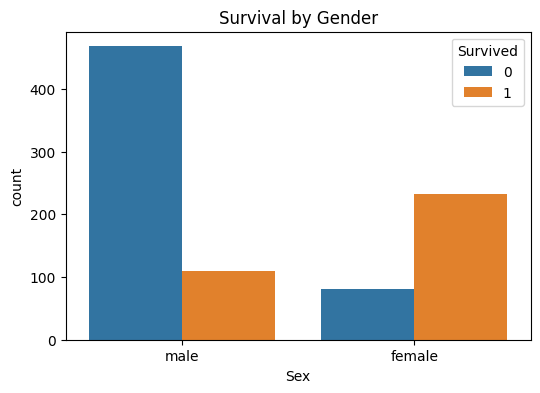

In [15]:
# Bar Chart

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.show()

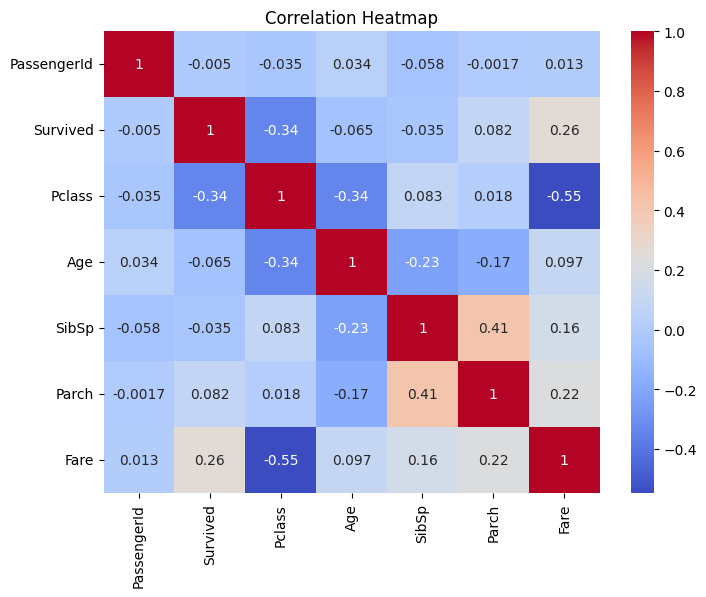

In [18]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Which feature most affects survival?

I think **Sex** has the strongest effect on survival because females had a much higher survival rate than males. This pattern is clearly visible in the bar chart. It reflects the historical "women and children first" evacuation policy followed during the Titanic disaster.